Choose one of the 3 possible functions:

1. f(x)=0 for all x belongs to {0,1}^n  ---> Constant
2. f(x)=1 for all x belongs to {0,1}^n  ---> Constant
3. f(x)=0 for half x belongs to {0,1}^n and 1 for other half  ---> Balanced

User Chose :  3

Number of bits :  3

f(x) array: [1, 0, 0, 0, 1, 1, 0, 1]


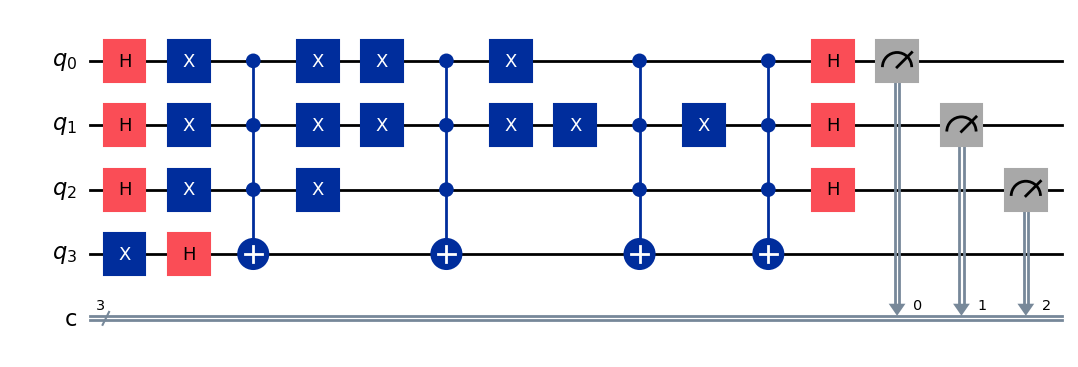

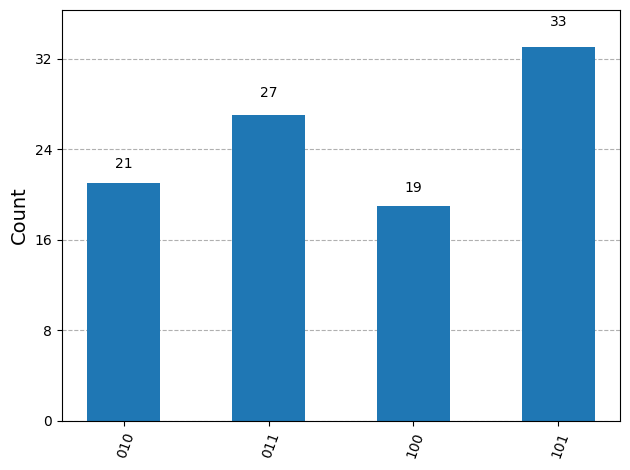


Measured Output: 101
Function is BALANCED


In [1]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from numpy import pi
from qiskit.quantum_info import *
from qiskit . visualization import plot_histogram
from numpy import sqrt
from IPython.display import Math, display
from qiskit.circuit.library import UnitaryGate
from numpy import pi, cos, sin, exp
from qiskit_aer import AerSimulator
from qiskit_aer.library import save_statevector
import random

print("Choose one of the 3 possible functions:\n")

print("1. f(x)=0 for all x belongs to {0,1}^n  ---> Constant")
print("2. f(x)=1 for all x belongs to {0,1}^n  ---> Constant")
print("3. f(x)=0 for half x belongs to {0,1}^n and 1 for other half  ---> Balanced")

choice = int(input("\nEnter choice (1-3): "))
bits_no = int(input("\nEnter no of bits(n): "))

print("\nUser Chose : ", choice)
print("\nNumber of bits : ", bits_no)

#Creating a random Balanced function

N = 2**bits_no

if choice == 1:
    f_array = [0] * N

elif choice == 2:
    f_array = [1] * N

elif choice == 3:
    f_array = [0] * (N//2) + [1] * (N//2)
    random.shuffle(f_array)

print("\nf(x) array:", f_array)

# Creating the circuit

q_reg = QuantumRegister(bits_no + 1, "q")
c_reg = ClassicalRegister(bits_no, "c")

circuit_1 = QuantumCircuit(q_reg, c_reg)

# Ancilla last qubit = |1>
circuit_1.x(bits_no)

# Hadamard on all qubits
for i in range(bits_no + 1):
    circuit_1.h(i)

# Oracle from f_array

for x in range(N):
    if f_array[x] == 1:
        binary_x = format(x, f"0{bits_no}b")

        for i, bit in enumerate(reversed(binary_x)):
            if bit == '0':
                    circuit_1.x(i)

        circuit_1.mcx(list(range(bits_no)), bits_no)

        for i, bit in enumerate(reversed(binary_x)):
            if bit == '0':
                circuit_1.x(i)

# Hadamard again on input qubits only
for i in range(bits_no):
    circuit_1.h(i)

# Measure input qubits
circuit_1.measure(list(range(bits_no)), list(range(bits_no)))

display(circuit_1.draw(output="mpl"))

sim = AerSimulator()
result = sim.run(circuit_1, shots=100).result()
counts = result.get_counts()

display(plot_histogram(counts))

measured_output = max(counts, key=counts.get)

print("\nMeasured Output:", measured_output)

if measured_output == "0" * bits_no:
    print("Function is CONSTANT")
else:
    print("Function is BALANCED")